# 04_14 Model Comparison Summary
Aggregate all metric JSON files from `reports/model_metrics`.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Tong hop ket qua tat ca model de benchmark cong bang theo cung split.
- Muc tieu ky thuat: Hien thi bang metric + bieu do so sanh theo tung model family.

,model_family,model_name,f1,accuracy,rmse,mae,r2,rules,freq_itemsets,train_rows,test_rows,transactions
0,classification,DecisionTreeClassifier,0.678628,0.776368,NaN,NaN,NaN,NaN,NaN,68887.0,14734.0,NaN
1,classification,GBTClassifier,0.678628,0.776368,NaN,NaN,NaN,NaN,NaN,68887.0,14734.0,NaN
2,classification,GBTClassifier_CV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69609.0,14916.0,NaN
3,classification,LinearSVC,0.678628,0.776368,NaN,NaN,NaN,NaN,NaN,68887.0,14734.0,NaN
4,classification,LogisticRegression,0.678628,0.776368,NaN,NaN,NaN,NaN,NaN,68887.0,14734.0,NaN
5,classification,LogisticRegression_CV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69609.0,14916.0,NaN
6,classification,NaiveBayes,0.694384,0.743790,NaN,NaN,NaN,NaN,NaN,68887.0,14734.0,NaN
7,classification,RandomForestClassifier,0.678628,0.776368,NaN,NaN,NaN,NaN,NaN,68887.0,14734.0,NaN
8,classification,RandomForest_CV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69609.0,14916.0,NaN
9,clustering,BisectingKMeans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65592.0,13967.0,NaN


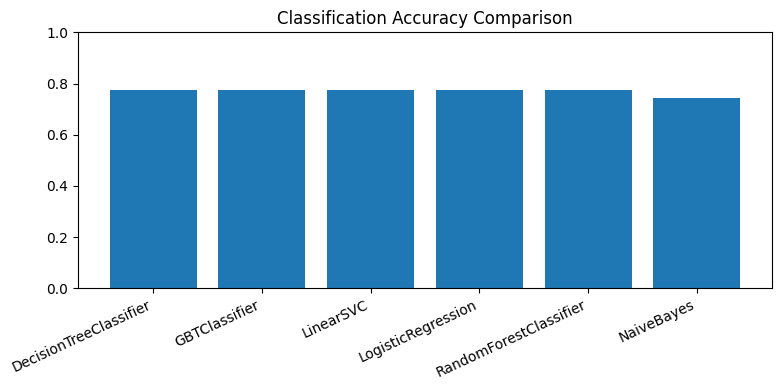

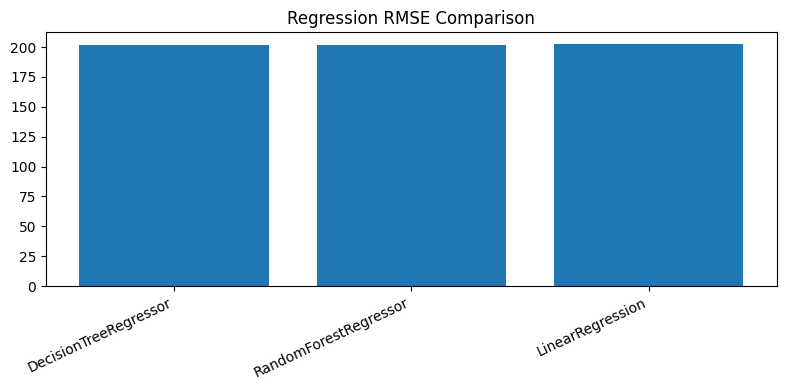

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_comparison_summary.csv


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
OUT_DIR=PROJECT_ROOT/'reports'
OUT_DIR.mkdir(parents=True, exist_ok=True)
rows=[]
for p in sorted(METRIC_DIR.glob('*.json')):
    try:
        rows.append(json.loads(p.read_text(encoding='utf-8')))
    except Exception as e:
        rows.append({'model_name':p.name,'error':str(e)})
summary=pd.DataFrame(rows)
if summary.empty:
    print('No metric json found. Run 04_01..04_13 first.')
else:
    order_cols=[c for c in ['model_family','model_name','f1','accuracy','rmse','mae','r2','silhouette','rules','freq_itemsets','train_rows','test_rows','rows','transactions'] if c in summary.columns]
    summary=summary[order_cols]
    display(summary)
    cls=summary[summary.get('model_family', pd.Series(dtype=str))=='classification'].copy()
    if not cls.empty and 'accuracy' in cls.columns:
        cls=cls.sort_values('accuracy', ascending=False)
        plt.figure(figsize=(8,4))
        plt.bar(cls['model_name'], cls['accuracy'])
        plt.title('Classification Accuracy Comparison')
        plt.xticks(rotation=25, ha='right')
        plt.ylim(0,1)
        plt.tight_layout()
        plt.show()
    reg=summary[summary.get('model_family', pd.Series(dtype=str))=='regression'].copy()
    if not reg.empty and 'rmse' in reg.columns:
        reg=reg.sort_values('rmse', ascending=True)
        plt.figure(figsize=(8,4))
        plt.bar(reg['model_name'], reg['rmse'])
        plt.title('Regression RMSE Comparison')
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()
    summary.to_csv(OUT_DIR/'model_comparison_summary.csv', index=False)
    print('Saved:', OUT_DIR/'model_comparison_summary.csv')